In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs

%matplotlib inline


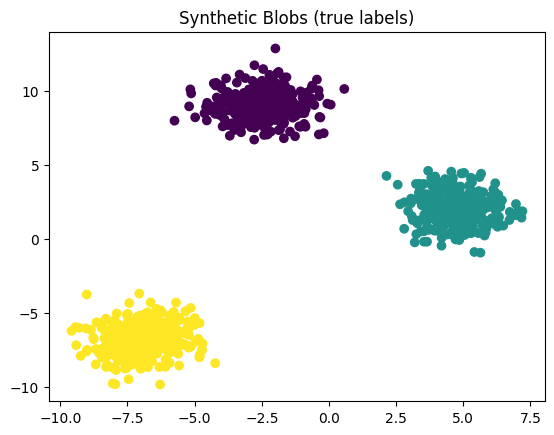

In [2]:
X, y = make_blobs(n_samples=1000, centers=3, n_features=2, random_state=42)
plt.scatter(X[:, 0], X[:, 1], c=y, cmap="viridis")
plt.title("Synthetic Blobs (true labels)")
plt.show()


In [3]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.33, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


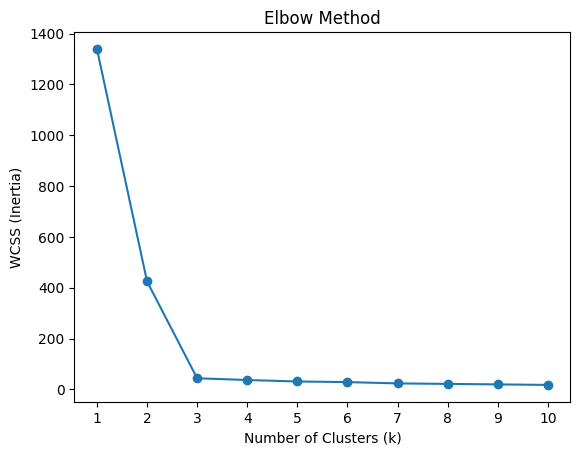

In [4]:
from sklearn.cluster import KMeans

wcss = []
k_values = range(1, 11)

for k in k_values:
    kmeans = KMeans(n_clusters=k, init="k-means++", random_state=42)
    kmeans.fit(X_train_scaled)
    wcss.append(kmeans.inertia_)  # inertia = WCSS

plt.plot(k_values, wcss, marker="o")
plt.xticks(k_values)
plt.xlabel("Number of Clusters (k)")
plt.ylabel("WCSS (Inertia)")
plt.title("Elbow Method")
plt.show()


In [5]:
from kneed import KneeLocator

kl = KneeLocator(k_values, wcss, curve="convex", direction="decreasing")
print("Elbow k:", kl.elbow)


Elbow k: 3


In [6]:
kmeans = KMeans(n_clusters=3, init="k-means++", random_state=42)
kmeans.fit(X_train_scaled)

train_labels = kmeans.labels_
test_labels = kmeans.predict(X_test_scaled)


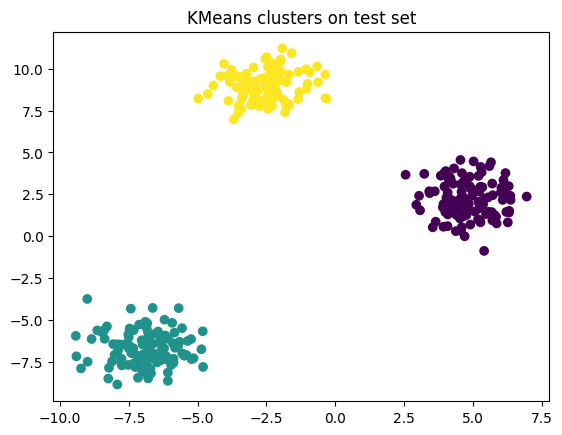

In [7]:
plt.scatter(X_test[:, 0], X_test[:, 1], c=test_labels, cmap="viridis")
plt.title("KMeans clusters on test set")
plt.show()


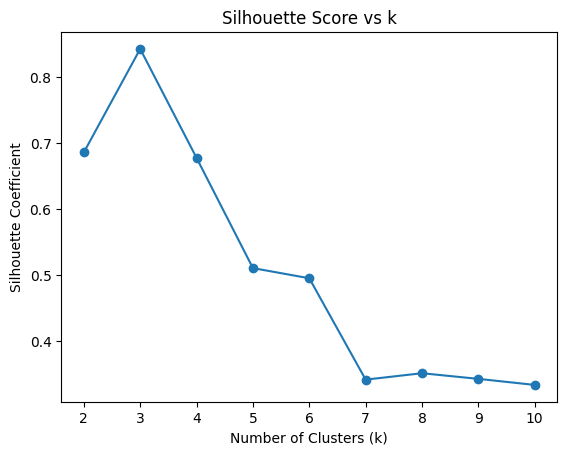

In [8]:
from sklearn.metrics import silhouette_score

silhouette_coefficients = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, init="k-means++", random_state=42)
    kmeans.fit(X_train_scaled)
    score = silhouette_score(X_train_scaled, kmeans.labels_)
    silhouette_coefficients.append(score)

plt.plot(range(2, 11), silhouette_coefficients, marker="o")
plt.xticks(range(2, 11))
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Coefficient")
plt.title("Silhouette Score vs k")
plt.show()


In [9]:
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
from sklearn.metrics import confusion_matrix
from scipy.optimize import linear_sum_assignment

# true labels from make_blobs
y_true = y_test
y_pred = test_labels

# ARI and NMI (label-invariant)
ari = adjusted_rand_score(y_true, y_pred)
nmi = normalized_mutual_info_score(y_true, y_pred)

print(f"ARI: {ari:.4f}")
print(f"NMI: {nmi:.4f}")

# Accuracy after optimal label matching
cm = confusion_matrix(y_true, y_pred)
row_ind, col_ind = linear_sum_assignment(-cm)  # maximize matches
accuracy = cm[row_ind, col_ind].sum() / cm.sum()

print(f"Matched Accuracy: {accuracy:.4f}")


ARI: 1.0000
NMI: 1.0000
Matched Accuracy: 1.0000
